<a href="https://colab.research.google.com/github/SquirrelCat235/Monthly-Temperature-Time-Series-Analysis-/blob/main/Monthly_Temp_Time_Series_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Forecasting of Monthly Temperature of India

This project models and forecasts monthly temperature data using:
- Trend modeling (Quadratic)
- Seasonal decomposition
- ARMA modeling of residuals
- Hybrid reconstruction (Trend + Seasonal + Residual)

## 📂 Data Source

The dataset used in this project is publicly available:

- **Dataset:** Annual and Seasonal Mean Temperature of India  
- **Source:** Data.gov.in (Open Government Data Platform India)  
- **Link:** https://www.data.gov.in/resource/monthly-seasonal-and-annual-mean-temperature-series-period-1901-2021

The dataset contains monthly temperature observations from 1901 to 2021.




## 📦 Install and Load Libraries

In [ ]:
install.packages(c("forecast","Kendall","tseries","TSA"))

library(forecast)
library(Kendall)
library(tseries)
library(TSA)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## 📂 Load Dataset

In [ ]:
data = read.csv("TEMP_ANNUAL_MEAN_1901-2021.csv")
temp.data = data[1:121, 2:13]

## 🔄 Data Arrangement (Monthly Series)

In [ ]:
temp.month = t(temp.data)

x = temp.month[,1]
for(i in 2:121)
{
  x = append(x, temp.month[,i])
}

x = as.numeric(x)

## 📈 Converting into Monthly Time Series

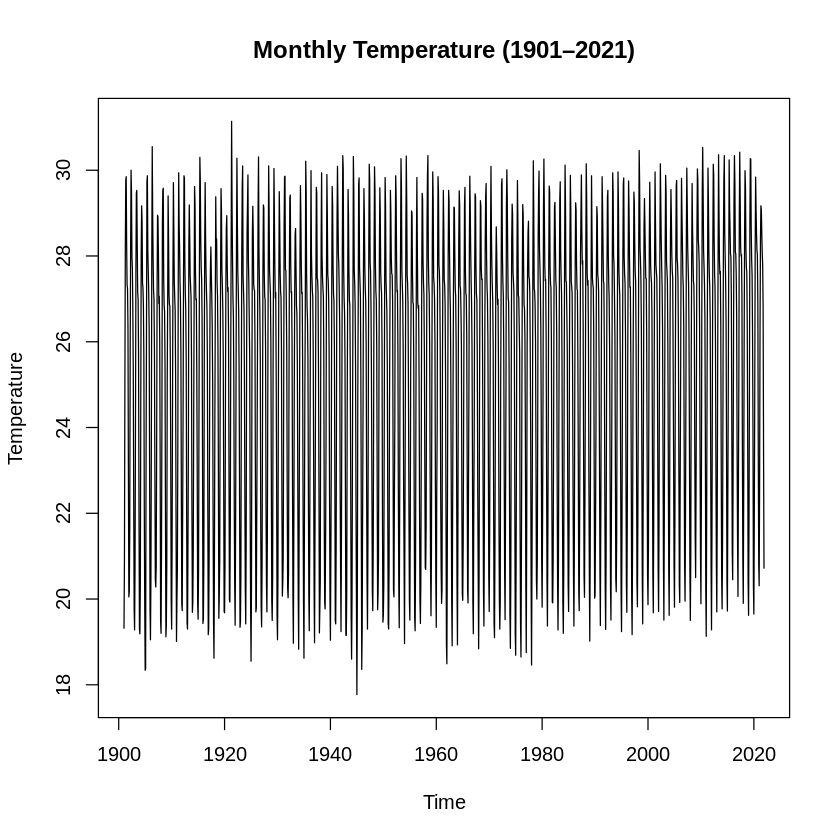

In [ ]:
data_temp = ts(x, start=c(1901,1), frequency=12)

plot(data_temp,
     main="Monthly Temperature (1901–2021)",
     xlab="Time",
     ylab="Temperature")

Interpretation:

From the plot, we make the following observations:

(i) There seems to be a slight upward increase in the monthly average temperatures over the
years i.e. an evolutive pattern might be present in the data which is dominated by a slightly
upward trend.  

(ii) Monthly fluctuations within the data are present. Hence seasonal variation (S) is present.
The intensity of these fluctuations seems to be constant over the years.

(iii) Cyclical fluctuation seems to be absent in the dataset.

## ✂️ Train-Test Split

In [ ]:
n = length(x)
m = ceiling(n * 0.95)

train = x[1:m]
test = x[(m+1):n]

Month_temp = ts(train, start=c(1901,1), frequency=12)
M.test_temp = ts(test, start=c(2016,1), frequency=12)

## 📊 Mann-Kendall Trend Test

In [ ]:
MannKendall(Month_temp)

tau = 0.0436, 2-sided pvalue =0.015364

## 📅 Annual Temperature Plot

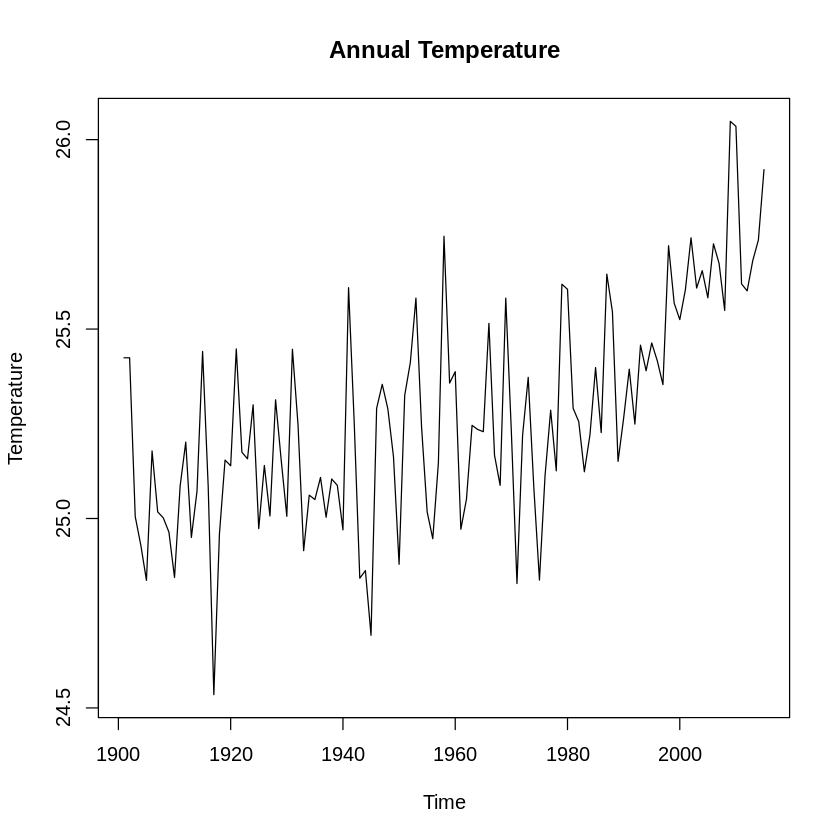

In [ ]:
annual_temp = aggregate(Month_temp, FUN=mean)
t_year = 1:length(annual_temp)

plot(annual_temp,
     main="Annual Temperature",
     ylab="Temperature")

## 📉 Selection of appropriate Trend Model

In [ ]:
fit_linear=lm(annual_temp ~ t_year)
fit_quad=lm(annual_temp ~ t_year + I(t_year^2))
fit_cubic=lm(annual_temp ~ t_year + I(t_year^2) + I(t_year^3))
fit_exp=lm(log(annual_temp) ~ t_year)
fit_log=lm(annual_temp ~ log(t_year))
fit_poly4=lm(annual_temp ~ t_year + I(t_year^2) + I(t_year^3) + I(t_year^4))

cat("AIC Values:\n")
print(AIC(fit_linear, fit_quad, fit_cubic, fit_exp,fit_log,fit_poly4))

cat("\nR-squared:\n")
print(c(
  linear = summary(fit_linear)$r.squared,
  quadratic = summary(fit_quad)$r.squared,
  cubic = summary(fit_cubic)$r.squared,
  exponential = summary(fit_exp)$r.squared,
  logarithmic = summary(fit_log)$r.squared,
  poly_degree4 = summary(fit_poly4)$r.squared))


AIC Values:
           df        AIC
fit_linear  3  -17.72814
fit_quad    4  -33.61846
fit_cubic   5  -34.53615
fit_exp     3 -760.72456
fit_log     3   15.21916
fit_poly4   6  -33.62237

R-squared:
      linear    quadratic        cubic  exponential  logarithmic poly_degree4 
   0.4091827    0.4943024    0.5069712    0.4082713    0.2131756    0.5116061 


## 📈 Graphical Comparison of Trends

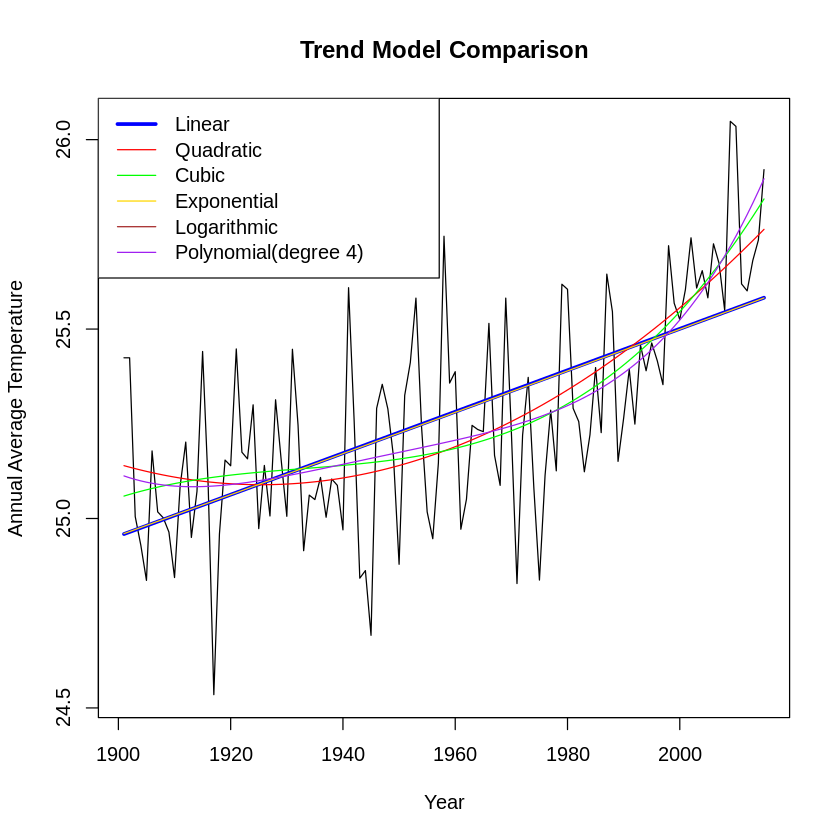

In [ ]:
plot(annual_temp, type = "l", col = "black",
     main = "Trend Model Comparison",
     ylab = "Annual Average Temperature",
     xlab = "Year")
lines(ts(fitted(fit_linear), start = start(annual_temp), frequency = 1),col = "blue",lwd=3)
lines(ts(fitted(fit_quad), start = start(annual_temp), frequency = 1),col = "red")
lines(ts(fitted(fit_cubic), start = start(annual_temp), frequency = 1),col = "green")
lines(ts(exp(fitted(fit_exp)), start = start(annual_temp), frequency = 1),col = "gold")
lines(ts(exp(fitted(fit_log)), start = start(annual_temp), frequency = 1), col = "brown")
lines(ts(fitted(fit_poly4), start = start(annual_temp), frequency = 1), col = "purple")
legend("topleft",
       legend = c("Linear", "Quadratic", "Cubic", "Exponential","Logarithmic",
       "Polynomial(degree 4)"),
       col = c("blue", "red", "green", "gold","brown","purple"),
       lwd=c(3,1,1,1,1,1))



Decision:
Among the fitted models, the quadratic trend provides a good balance between model fit and simplicity.

Although higher-order models show slightly better R-squared values, the improvement is marginal and may lead to overfitting. The exponential model is not directly comparable due to log transformation.

Hence, the quadratic model is selected for further analysis.

## 📈 Monthly Trend Equation Conversion

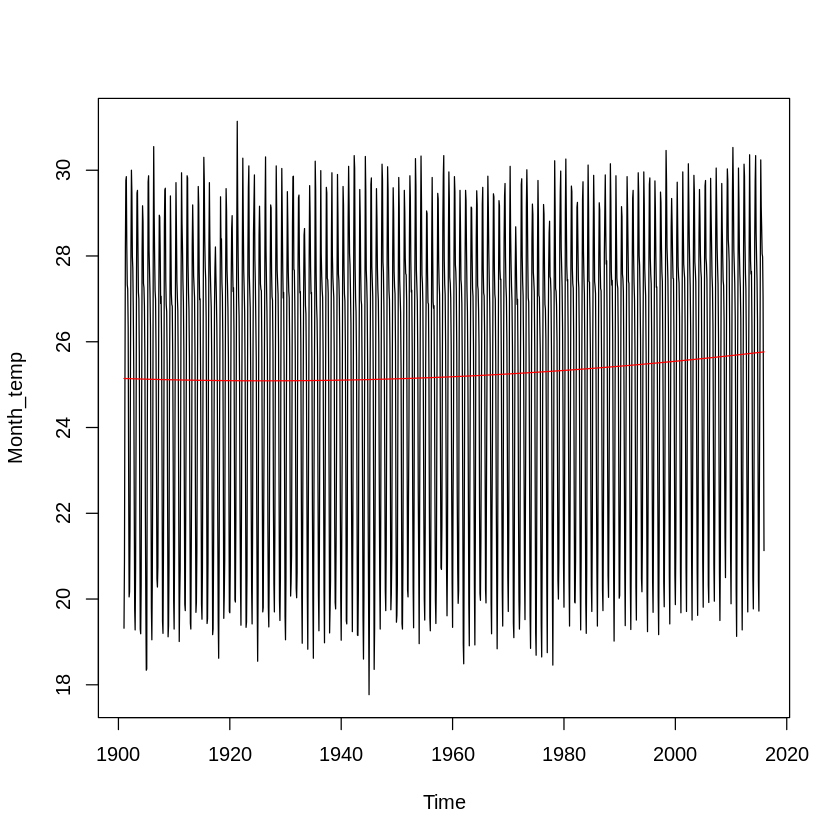

In [ ]:
fit = fit_quad

b  = coef(fit)[1]
b1 = coef(fit)[2]
b2 = coef(fit)[3]

t = 1:length(train)

Tt_hat = b + (b1/12)*(t+0.5) + (b2/144)*(t+0.5)^2
Tr = ts(Tt_hat, start=c(1901,1), frequency=12)

plot(Month_temp)
lines(Tr, col="red")

## 🔻 Detrending the dataset

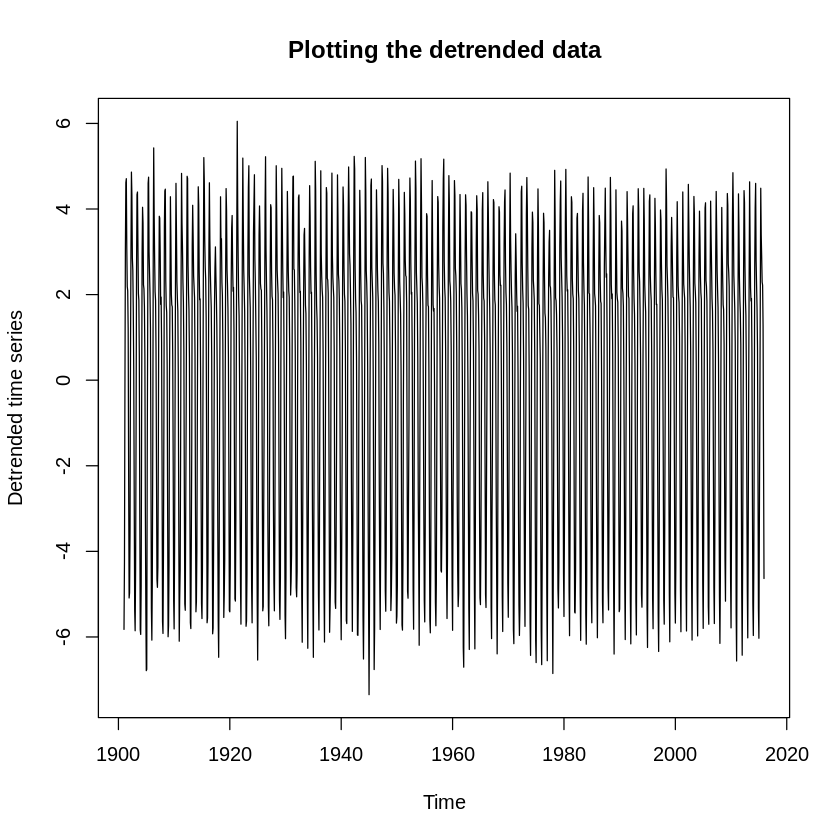

In [ ]:
detr = Month_temp - Tr
plot(detr,main="Plotting the detrended data",ylab="Detrended time series")


## 🔄 Seasonal Decomposition


[1] -5.8246583 -3.9978851 -0.5063306  2.6158315  4.4202533  3.9298043
 [7]  2.5518760  2.0757725  1.8031461  0.5469534 -2.4442840 -5.1704791

[1] 1.554312e-15

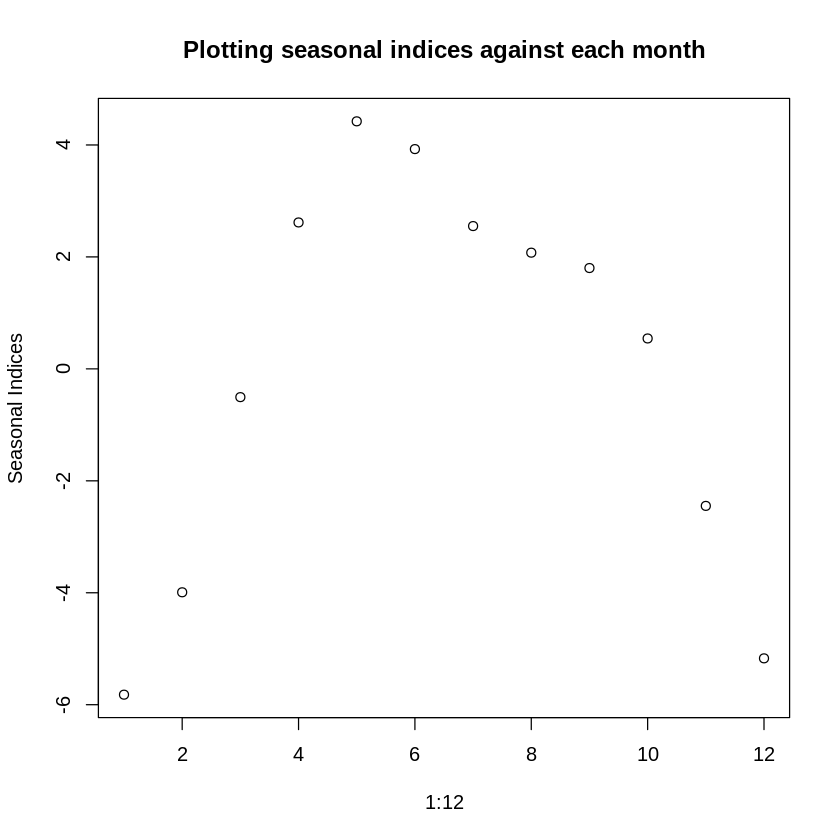

In [ ]:
#1. Calculating it manually

M=as.vector(detr)
M=matrix(detr,ncol=12,byrow=T)
S=apply(M,2,FUN=mean)
seas=S-mean(S)
seas
sum(seas)#Almost equals to 0

#2. Using the decompose function
S=decompose(Month_temp,type="additive")

plot(1:12,S$figure,main="Plotting seasonal indices against each month",ylab="Seasonal Indices")


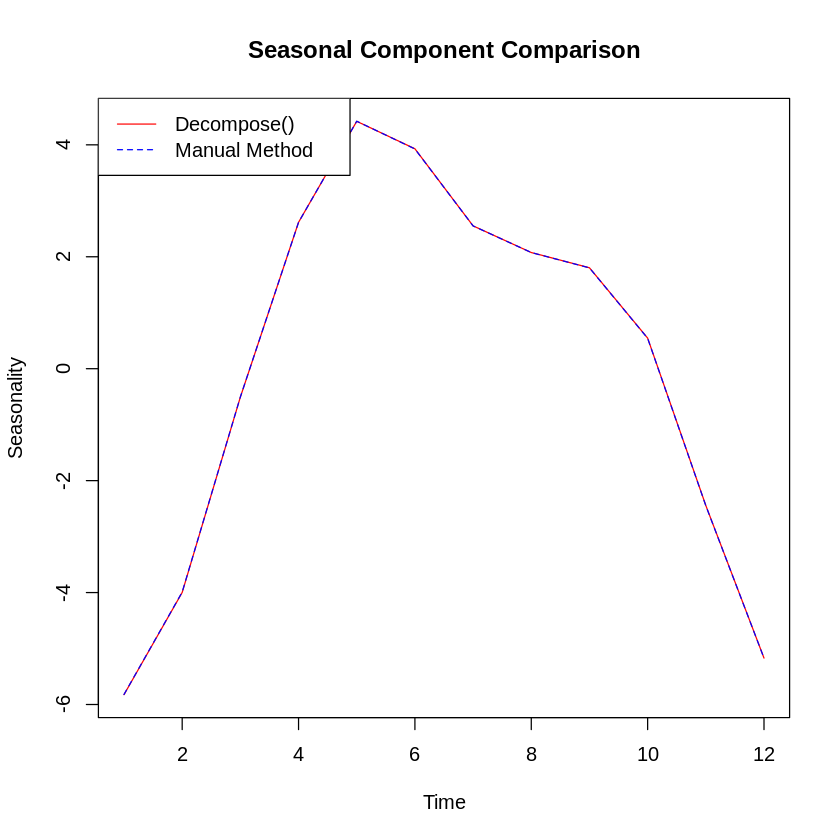

In [ ]:
##Comparing the values from the two methods
#(The values are approximately equal)
plot(seas, type = "l", col = "red",
     main = "Seasonal Component Comparison",
     ylab = "Seasonality", xlab = "Time")
lines(S$figure, col = "blue",lty=2)

legend("topleft",
       legend = c("Decompose()", "Manual Method"),
       lty = c(1,2),
       col = c("red", "blue"))

## 🔍 Residual Analysis

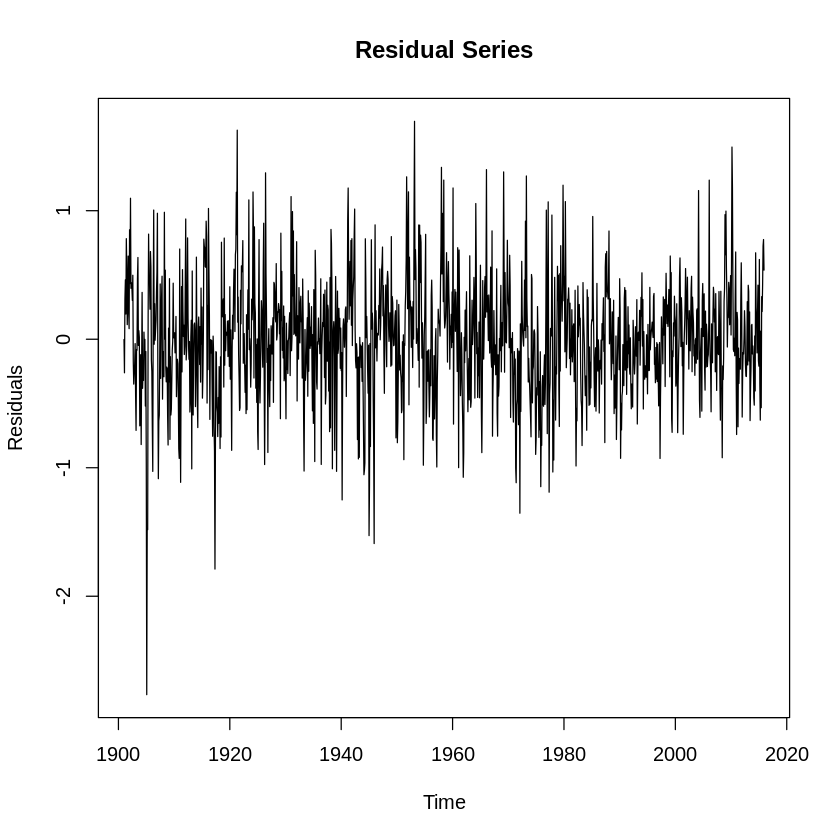

In [ ]:
Se=S$figure
res = detr - Se

plot(res, main = "Residual Series", ylab = "Residuals")

## 🧪 Testing the Residual Series

In [ ]:
#Checking the p value
adf.test(res)
Box.test(res)


Warning message in adf.test(res):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  res
Dickey-Fuller = -8.2133, Lag order = 11, p-value = 0.01
alternative hypothesis: stationary



	Box-Pierce test

data:  res
X-squared = 184.23, df = 1, p-value < 2.2e-16


Observation: Through the ADF test, we can say that the residual series is stationary in this case, that
is, differencing is not required which implies that the cyclical variation is absent in the
dataset.


From the result of Box-Pierce test, we can conclude that the residual series are autocorrelated.

This further implies that there is significant dependence among the residuals and therefore we can fit an appropriate model to
 predict future values of temperature.

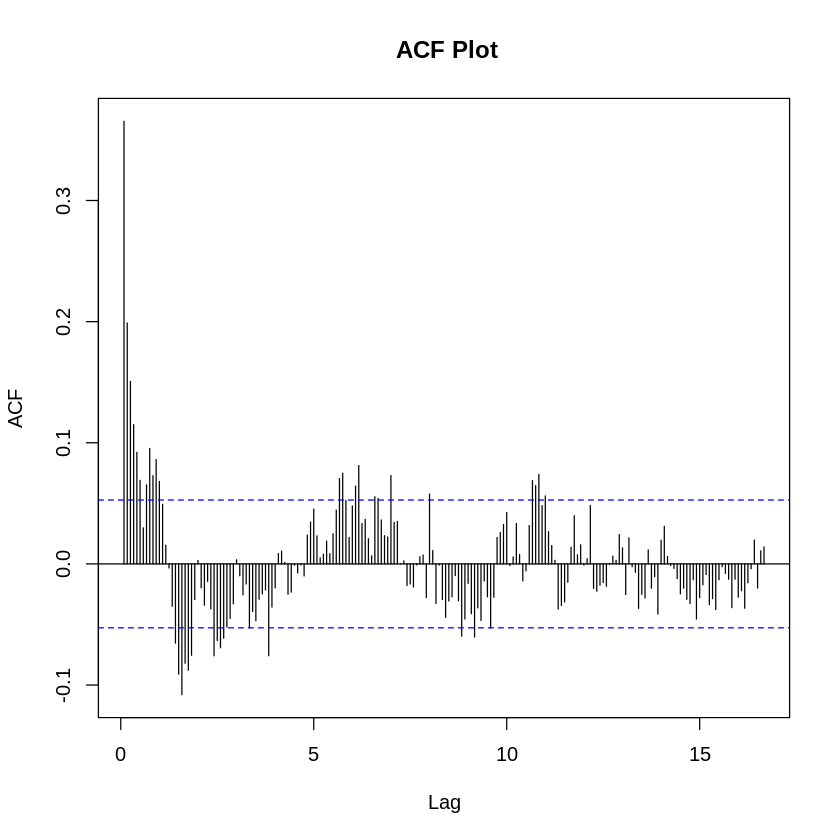

AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x x x x x x o x x x x  x  o  o 
1 x x o o o o o o o o o  o  o  o 
2 x x o o o o o o o o o  o  o  o 
3 x x o o o o o o o o o  o  o  o 
4 x x o o o o o o o o o  o  o  o 
5 x x x o o o o o o o o  o  o  o 
6 x o x o x x o o o o o  o  o  o 
7 x o x x x x o x o o x  o  o  o 


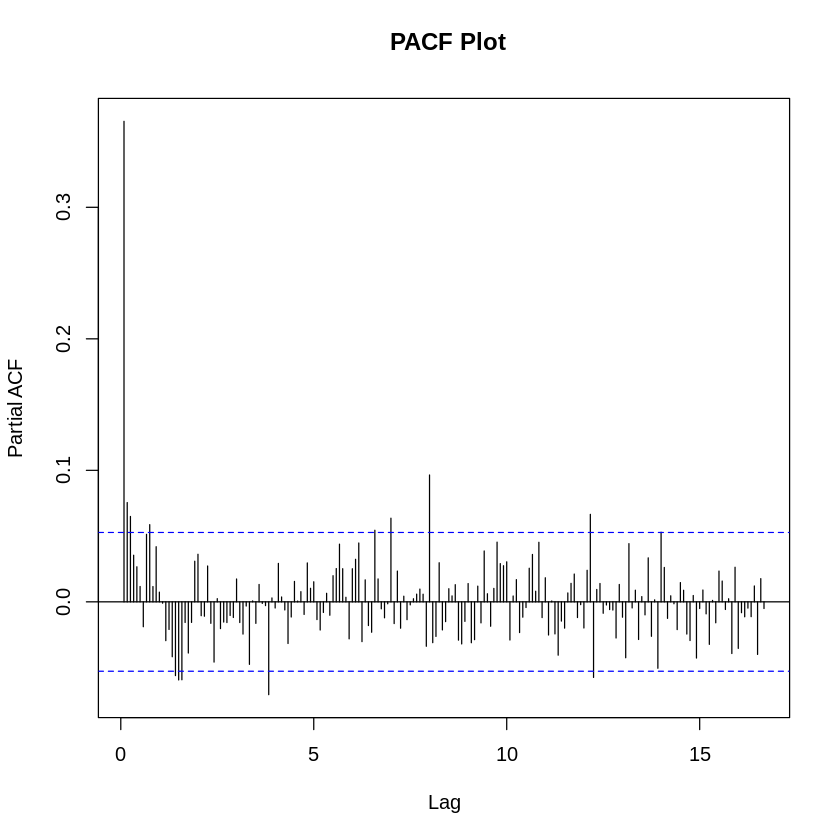

In [ ]:
# ACF and PACF Plot

acf(res, lag.max = 200, main = " ACF Plot")
pacf(res, lag.max = 200, main = " PACF Plot")

#  Extended ACF Analysis
eacf(res)

## ⚙️ ARMA Modeling

In [ ]:
fit=Arima(res, order = c(1,0,2))
fit

fit1=Arima(res, order = c(2,0,2))
fit1

fit2=Arima(res, order = c(3,0,2))
fit2

AIC(fit, fit1, fit2)

#Further validation using autoarima()
library(forecast)
auto.arima(res)

Series: res 
ARIMA(1,0,2) with non-zero mean 

Coefficients:
         ar1      ma1      ma2    mean
      0.8010  -0.4741  -0.1126  0.0033
s.e.  0.0678   0.0755   0.0431  0.0237

sigma^2 = 0.1802:  log likelihood = -773.96
AIC=1557.92   AICc=1557.97   BIC=1584.07

Series: res 
ARIMA(2,0,2) with non-zero mean 

Coefficients:
         ar1      ar2      ma1      ma2    mean
      0.9954  -0.1369  -0.6674  -0.0334  0.0021
s.e.  0.3018   0.2198   0.3027   0.1436  0.0241

sigma^2 = 0.1803:  log likelihood = -773.75
AIC=1559.49   AICc=1559.56   BIC=1590.87

Warning message in sqrt(diag(x$var.coef)):
“NaNs produced”


Series: res 
ARIMA(3,0,2) with non-zero mean 

Coefficients:
         ar1      ar2     ar3      ma1     ma2    mean
      1.3569  -0.5014  0.0563  -1.0294  0.2172  0.0031
s.e.     NaN      NaN     NaN      NaN     NaN  0.0243

sigma^2 = 0.1805:  log likelihood = -773.75
AIC=1561.5   AICc=1561.58   BIC=1598.11

,df,AIC
,<dbl>,<dbl>
fit,5,1557.922
fit1,6,1559.494
fit2,7,1561.496


Series: res 
ARIMA(1,0,2) with zero mean 

Coefficients:
         ar1      ma1     ma2
      0.8017  -0.4748  -0.113
s.e.  0.0675   0.0752   0.043

sigma^2 = 0.1801:  log likelihood = -773.97
AIC=1555.94   AICc=1555.97   BIC=1576.86

## ⚙️ ARMA Model Selection

Based on the ACF, PACF, and EACF analysis, an ARMA(1,2) model was selected.

The PACF cuts off after lag 1, indicating an AR(1) component, while the ACF shows significant spikes at initial lags, suggesting MA terms.

The model provides a good balance between fit and simplicity and adequately captures the residual structure.

## 🧪 Residual Diagnostics

In [ ]:
resid = residuals(fit)

MAPE = mean(abs(resid/res)) * 100
MAPE

Box.test(resid, lag=20, type="Ljung")

[1] 194.8323


	Box-Ljung test

data:  resid
X-squared = 26.52, df = 20, p-value = 0.1493


## 🔮 Forecast on Test Data

[1] 0.267304522 0.189496957 0.152453741 0.122780722 0.099011509 0.079971469
 [7] 0.064719676 0.052502412 0.042715920 0.034876570 0.028596953 0.023566742
[13] 0.019537353 0.016309659 0.013724154 0.011653067 0.009994047 0.008665110
[19] 0.007600581 0.006747853 0.006064785 0.005517622 0.005079324 0.004728230
[25] 0.004446991 0.004221707 0.004041247 0.003896691 0.003780897 0.003688141
[31] 0.003613840 0.003554322 0.003506646 0.003468456 0.003437864 0.003413359
[37] 0.003393729 0.003378005 0.003365409 0.003355320 0.003347238 0.003340764
[43] 0.003335578 0.003331423 0.003328096 0.003325430 0.003323295 0.003321585
[49] 0.003320214 0.003319117 0.003318238 0.003317534 0.003316970 0.003316518
[55] 0.003316156 0.003315866 0.003315633 0.003315447 0.003315298 0.003315179
[61] 0.003315083 0.003315007 0.003314945 0.003314896 0.003314857 0.003314825
[67] 0.003314800 0.003314780 0.003314764 0.003314751 0.003314740 0.003314732

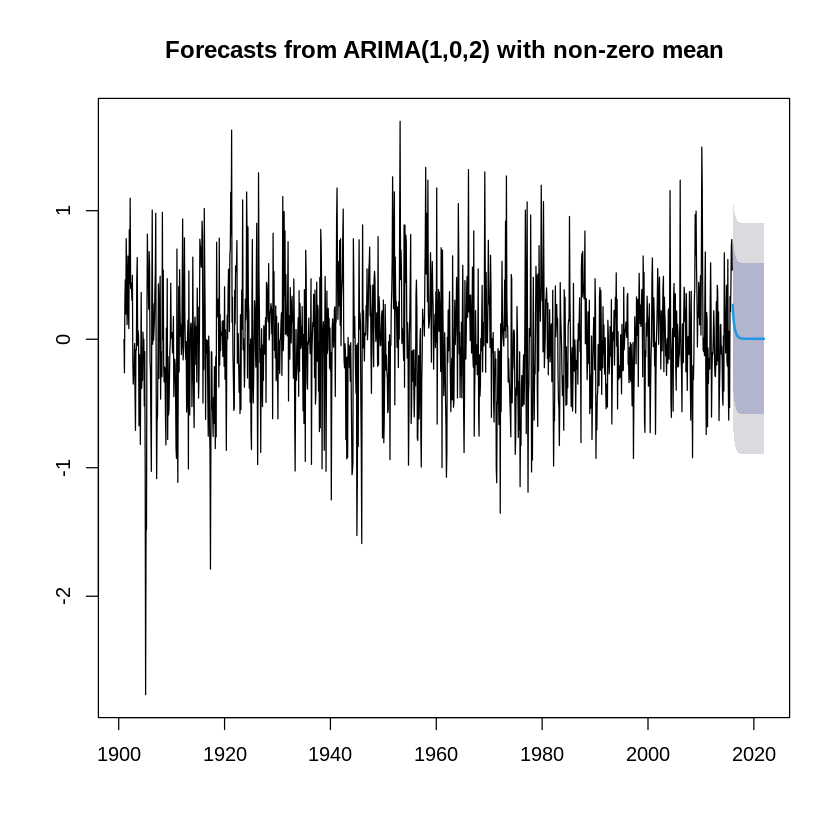

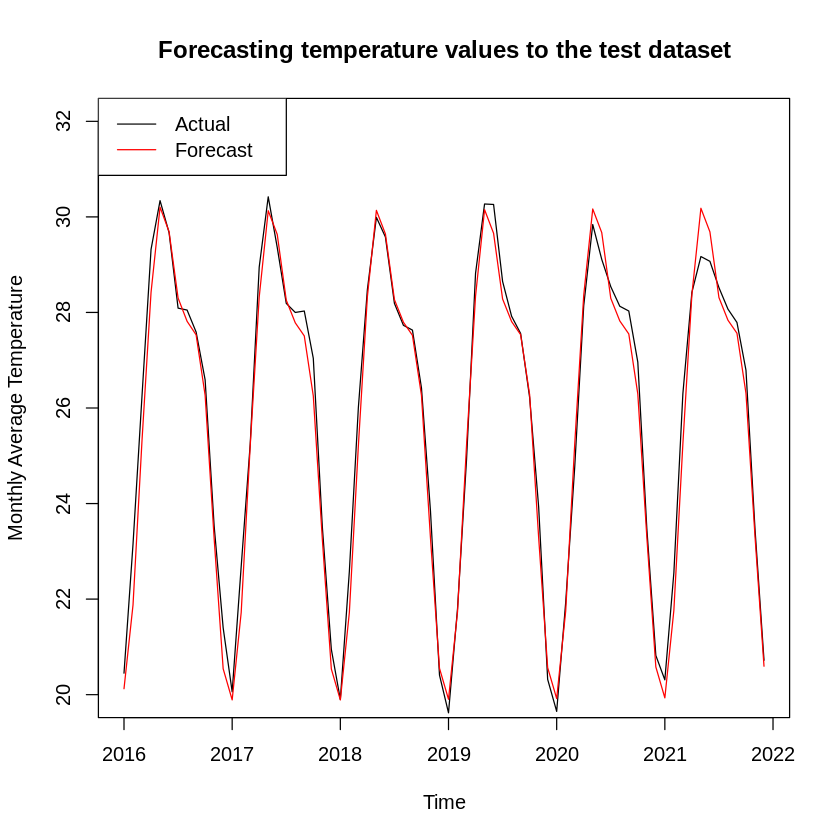

In [ ]:
f_value=forecast(fit,h=n-m)
plot(f_value)
p_f=as.numeric(f_value$mean);p_f

T_test = tail(Tr, length(test))
Se_test = tail(Se, length(test))

r=p_f+T_test+Se_test
r=ts(r,start=2016,frequency=12)

plot(M.test_temp,main="Forecasting temperature values to the test dataset",ylim=c(20,32),ylab="Monthly Average Temperature")
points(r,col="red",type="l")

legend("topleft",
legend=c("Actual","Forecast"),
col=c("black","red"),
lty=1)


## 📏 Accuracy Evaluation

In [ ]:
MAPE_test = mean(abs((M.test_temp - r)/M.test_temp)) * 100
MAPE_test

MAE = mean(abs(M.test_temp - r))
MAE

[1] 1.424539

[1] 0.361956

## 📏 Model Accuracy

The model achieves a Mean Absolute Percentage Error (MAPE) of approximately **1.43%** and a Mean Absolute Error (MAE) of **0.36**.

The low MAPE indicates that the model predictions are quite accurate, with an average deviation of around 1.43% from the actual values.

The MAE value suggests that the average absolute error in temperature prediction is relatively small, indicating good model performance.

## 🚀 Future Forecast (2022–2032)

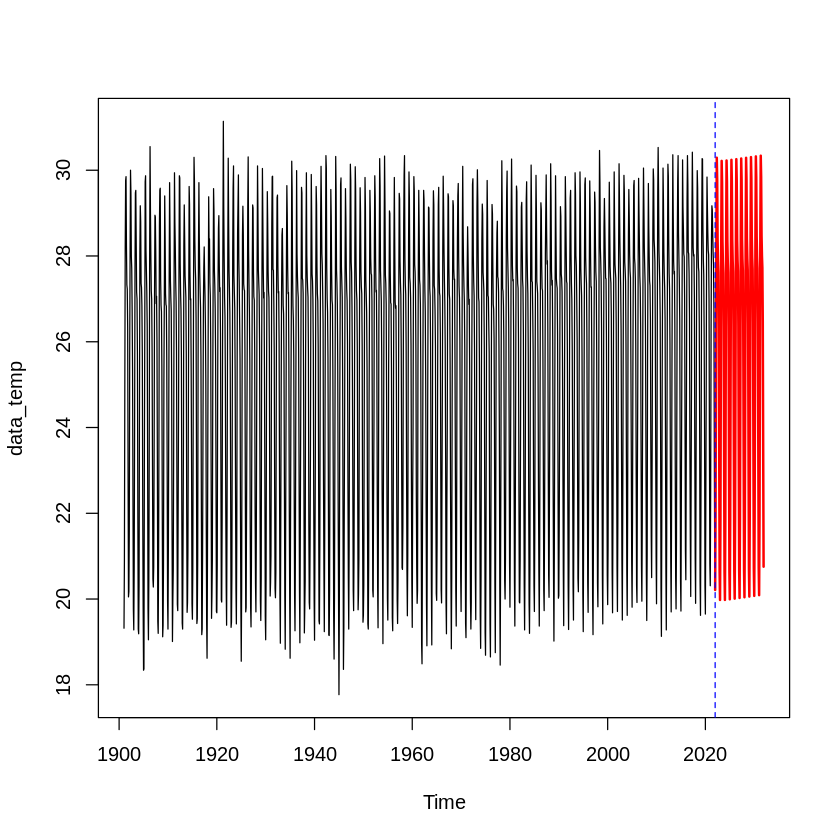

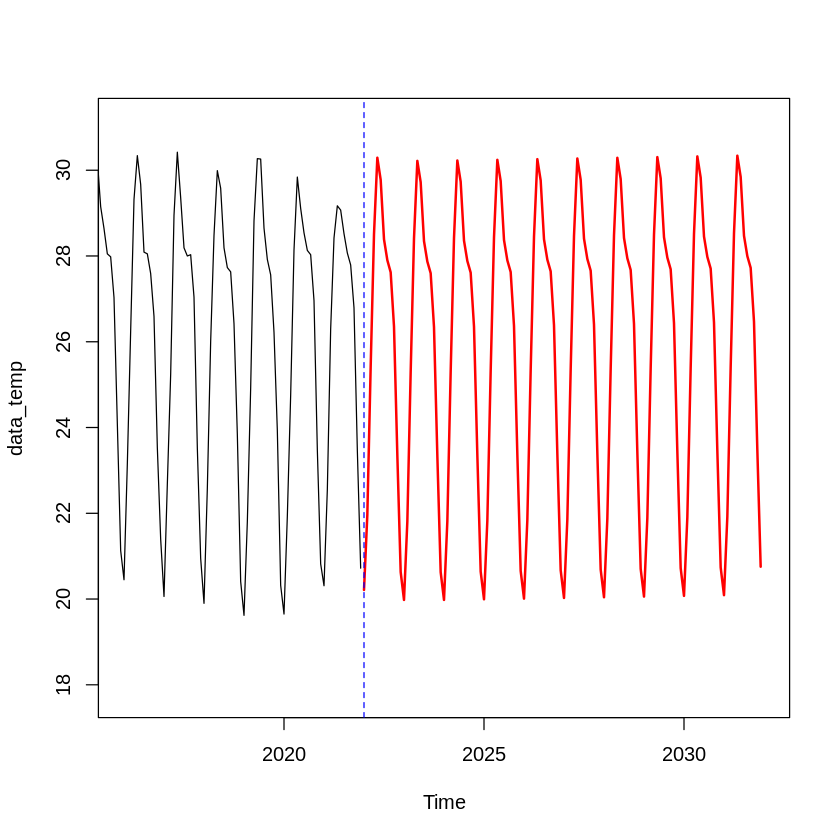

In [ ]:
h_future = 120

f_future = forecast(fit, h = h_future)
res_future = as.numeric(f_future$mean)

t_future = (length(Tr)+1):(length(Tr)+h_future)

T_future = b + (b1/12)*(t_future+0.5) + (b2/144)*(t_future+0.5)^2
Se_future = rep(Se, length.out = h_future)

Y_future = T_future + Se_future + res_future
Y_future_ts = ts(Y_future, start=c(2022,1), frequency=12)

plot(data_temp, xlim=c(1901,2032))
lines(Y_future_ts, col="red", lwd=2)
abline(v=2022, col="blue", lty=2)

plot(data_temp, xlim=c(2016,2032))
lines(Y_future_ts, col="red", lwd=2)
abline(v=2022, col="blue", lty=2)

## 🚀 Future Forecast Interpretation (2022–2032)

The forecasted temperature values indicate a continued upward trend over the next decade.

The increasing trend component suggests a gradual rise in average temperature, while the seasonal pattern remains consistent across years.

This indicates that although short-term fluctuations persist, the overall long-term behavior reflects a steady warming pattern.

However, the forecast assumes that historical patterns continue and does not account for external factors such as climate anomalies or policy changes.